# Mortgage Prepayment Simulation — Monte Carlo and Stochastic Rate Modelling
### Simulation Engine

This is the final notebook of the project **"Mortgage Prepayment Simulation — Monte Carlo and Stochastic Rate Modelling"**.

The notebook simulates 5000 interest rate paths using the CIR Interest Rate Model for 360 months. Using these simulated interest rate paths, we simulate the mortgage rates for 360 months. Thereafter, aggregate loan balances are estimated for the next 120 months. The aggregate loan balances are then used to estimate the annual prepayment rates on the pool of loans. 

The notebook shows the plot of monthly aggregate loan balances for a few interest rate paths. We also look athe distirbution of aggregate loan balance and annual prepayment rate at the end of first year. These distributions help us understand the prepayment risk in one-year time horizon. 

The notebook then shows sensitivity test of rising and falling interest rates by changing the base interest rate from 0.05. The base interest rate would be shifted by +/-100bps.  


In [1]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import import_ipynb
import importlib
np.random.seed(42)

In [2]:
#Import other notebooks for the project
stochastic_paths_notebook = importlib.import_module('01_StochasticInterestRateModels')
calibration_notebook = importlib.import_module('02_CalibratingInterestRateModels')
mortgage_engine_notebook = importlib.import_module('03_MortgageEngine')

In [3]:
#Initial Parameters for Simulating interest rate paths:
initial_rate = 0.05
a = calibration_notebook.kappa_param_cir_fixed_theta
b = calibration_notebook.theta
sigma = calibration_notebook.sigma_param_cir_fixed_theta
T = 30
steps = 360
dt = T/steps
number_of_paths = 5000

In [4]:
#Set Evaluation Date
evaluation_date = pd.to_datetime('01-01-2025',format="%d-%m-%Y")

#Load Mortgage Data
mortgage_data = mortgage_engine_notebook.mortgage_data

#Transform Mortgage Data
mortgage_data['Inception Date']=pd.to_datetime(mortgage_data['Inception Date'],format="%d-%m-%Y")
mortgage_data['Orig Interest Rate'] = mortgage_data['Orig Interest Rate']/100
mortgage_data['Age on Evaluation Date'] = mortgage_data.apply(
    lambda x: mortgage_engine_notebook.age_of_the_loan(evaluation_date,x['Inception Date']), axis=1
)
mortgage_data['Loan Balance on Evaluation Date'] = mortgage_data.apply(
    lambda x: mortgage_engine_notebook.loan_upb_at_given_date(age=x['Age on Evaluation Date'], orig_loan_bal=x['Original Loan Balance'],annual_rate=x['Orig Interest Rate'],total_payments=360,prepayment_flag=0),axis=1
)

#Convert to arrays for indexing
rates = mortgage_data['Orig Interest Rate'].values
ltv = mortgage_data['Original LTV'].values
fico = mortgage_data['Original FICO'].values
age_eval = mortgage_data['Age on Evaluation Date'].values
orig_balance = mortgage_data['Original Loan Balance'].values
eval_balance = mortgage_data['Loan Balance on Evaluation Date'].values

In [5]:
#Define a function to simulate aggregate balances and annual prepay rates
def simulate_balances_prepay_rates(initial_rate,a,b,sigma,T,steps,number_of_paths):

    #Simulate Interest Rate Path using the CIR model (can choose the model here)
    short_term_paths=stochastic_paths_notebook.simulate_paths_based_on_chosen_model(model='CIR',initial_rate=initial_rate,a=a,b=b,sigma=sigma,T=30,steps=360,number_of_paths=5000)
    interest_rate_paths = calibration_notebook.intercept+calibration_notebook.beta*short_term_paths
    
    #Simulate Aggregate Balances 
    #Assumes a 2% spread over short term interest rates when comparing with mortgage rates
    aggregate_balances = np.zeros((number_of_paths,121))
    aggregate_balances[:,0] = mortgage_data['Loan Balance on Evaluation Date'].sum()/10e5

    for i in range(number_of_paths):
        loan_balance = np.zeros((mortgage_data.shape[0], 121))
        loan_balance[:,0] = eval_balance
        for j in range(1,121):
            for k in range(mortgage_data.shape[0]):
                if loan_balance[k,j-1]==0:
                    continue
                #Check age of the loan
                age_of_the_loan = age_eval[k]+j
                #Estimate prepayment flag
                prepay_flag = mortgage_engine_notebook.prepay_flag(rates[k]-interest_rate_paths[i,j],ltv[k],fico[k])
                #Update Loan Balance in loan_balance_df
                loan_balance[k,j]=mortgage_engine_notebook.loan_upb_at_given_date(age_of_the_loan,orig_balance[k],rates[k], 360,prepay_flag)
            aggregate_balances[i,j]=loan_balance[:,j].sum()/10e5
    
    #Simulate Aggregate Monthly Scheduled Payments
    aggregate_scheduled_payments = np.zeros((1,120))
    schd_pay = np.zeros((mortgage_data.shape[0], 120))
    for j in range(120):
        for k in range(mortgage_data.shape[0]):
            #Check age of the loan
            start_age = age_eval[k]+j
            end_age = start_age+1
            if end_age>360:
                continue
            #Update SP in schd_pay array
            schd_pay[k,j]=mortgage_engine_notebook.loan_upb_at_given_date(start_age,orig_balance[k],rates[k],360,0)-mortgage_engine_notebook.loan_upb_at_given_date(end_age,orig_balance[k],rates[k],360,0)
        aggregate_scheduled_payments[0,j]=schd_pay[:,j].sum()/10e5
    
    #Simulate Monthly Prepayment Rates
    monthly_prepay_rates = np.zeros((number_of_paths,120))
    for i in range(number_of_paths):
        for j in range(120):
            monthly_prepay_rates[i,j]=max((aggregate_balances[i,j]-aggregate_scheduled_payments[0,j]-aggregate_balances[i,j+1])/(aggregate_balances[i,j]-aggregate_scheduled_payments[0,j]),0)
    
    #Annual Prepayment Rates Calculations
    annual_prepay_rates = np.zeros((number_of_paths,10))
    for i in range(number_of_paths):
        for j in range(10):
            annual_prepay_rates[i,j]=(1+monthly_prepay_rates[i][13*j:(13*(j+1)-1)].mean())**12-1
    
    return aggregate_balances, annual_prepay_rates

In [6]:
#Simulating Aggregate Balances and Prepay Rates
aggregate_balances, annual_prepay_rates = simulate_balances_prepay_rates(initial_rate,a,b,sigma,T,steps,number_of_paths)

Text(0, 0.5, 'Aggregate Balance ($ millions)')

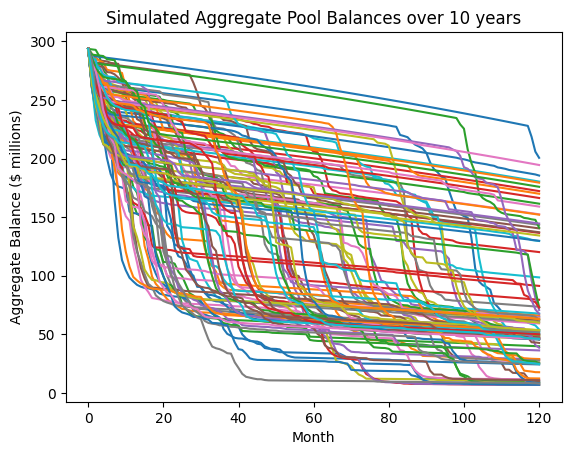

In [7]:
#Plot of the simulated pool balances across 10 years
for z in range(100):
    plt.plot(aggregate_balances[z])
plt.title('Simulated Aggregate Pool Balances over 10 years')
plt.xlabel('Month')
plt.ylabel('Aggregate Balance ($ millions)')

The plot shows 100 of 5,000 simulated aggregate pool balance paths over 120 months. The downward trend reflects scheduled amortisation and prepayments, while the dispersion across paths is driven by variability in interest rate paths and the resulting prepayment behaviour.

The average pool balance after one year is: 213.41
The 90th percentile of pool balance is: 261.86
The 95th percentile of pool balance is: 270.10


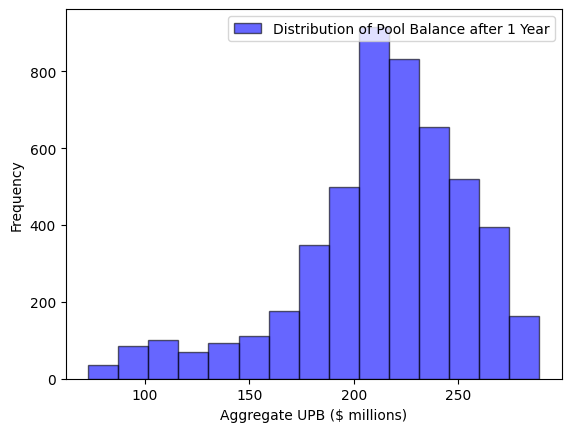

In [8]:
#Distirbution of pool balance after one year
plt.hist(aggregate_balances[:,12],bins=15, alpha=0.6, color='b', label='Distribution of Pool Balance after 1 Year', edgecolor='black')
plt.legend()
plt.xlabel('Aggregate UPB ($ millions)')
plt.ylabel('Frequency')

#Mean, 90th and 95th percentile of pool balances after one year
print(f"The average pool balance after one year is: {np.mean(aggregate_balances[:,12]):.2f}")
print(f"The 90th percentile of pool balance is: {np.quantile(aggregate_balances[:,12],0.9):.2f}")
print(f"The 95th percentile of pool balance is: {np.quantile(aggregate_balances[:,12],0.95):.2f}")

The distribution of aggregate pool balance after one year across 5,000 simulated paths. The left skew reflects that most paths cluster around $200-250 million, with a thin tail of lower balances driven by high prepayment scenarios where rates fall significantly.

The average CPR for 1st Year is: 0.39
The 90th percentile of CPR in Year 1 is: 0.74
The 95th percentile of CPR in Year 1 is: 1.17


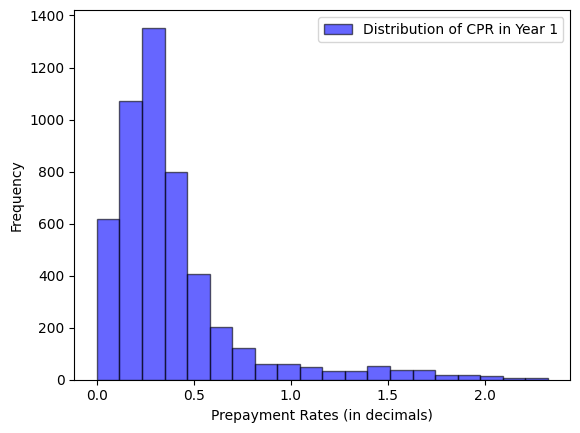

In [9]:
#Distirbution of CPR in year 1 
plt.hist(annual_prepay_rates[:,0],bins=20, alpha=0.6, color='b', label='Distribution of CPR in Year 1', edgecolor='black')
plt.legend()
plt.xlabel('Prepayment Rates (in decimals)')
plt.ylabel('Frequency')


#Mean, 90th and 95th percentile of CPR in year 1
print(f"The average CPR for 1st Year is: {np.mean(annual_prepay_rates[:,0]):.2f}")
print(f"The 90th percentile of CPR in Year 1 is: {np.quantile(annual_prepay_rates[:,0],0.9):.2f}")
print(f"The 95th percentile of CPR in Year 1 is: {np.quantile(annual_prepay_rates[:,0],0.95):.2f}")

The distribution of annual CPR in year 1 across 5,000 simulated paths. The right skew reflects that most loans prepay at low rates (10-20% CPR) with a long tail of high prepayment scenarios, consistent with the prime-heavy portfolio where borrowers have the credit quality to refinance when rates are favourable.

Text(0, 0.5, 'CPR')

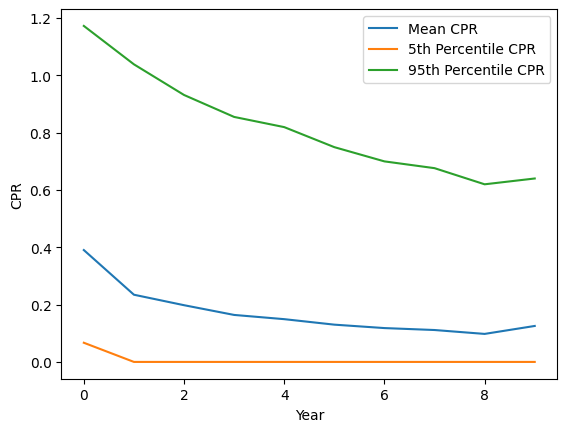

In [10]:
#Plot mean, 5th and 95th percentile CPR path
mean_cpr = np.mean(annual_prepay_rates, axis=0)
p5_cpr = np.quantile(annual_prepay_rates, 0.05, axis=0)
p95_cpr = np.quantile(annual_prepay_rates, 0.95, axis=0)
years = np.arange(10)

plt.plot(years, mean_cpr, label="Mean CPR")
plt.plot(years, p5_cpr, label="5th Percentile CPR")
plt.plot(years, p95_cpr, label="95th Percentile CPR")
plt.legend()
plt.xlabel("Year")
plt.ylabel("CPR")

In [11]:
#Sensitivity Analysis shifting base rated by +/- 100bps
aggregate_balances_up, annual_prepay_rates_up = simulate_balances_prepay_rates(initial_rate+0.01,a,b,sigma,T,steps,number_of_paths)
aggregate_balances_down, annual_prepay_rates_down = simulate_balances_prepay_rates(initial_rate-0.01,a,b,sigma,T,steps,number_of_paths)

In [12]:
#Results DataFrame
scenario_results = pd.DataFrame({
    'Scenario': ['Falling Rates (-100bps)', 'Base Case', 'Rising Rates (+100bps)'],
    'Mean CPR Year 1': [
        np.mean(annual_prepay_rates_down[:,0]), np.mean(annual_prepay_rates[:,0]), np.mean(annual_prepay_rates_up[:,0])
    ],
    '95th Pct CPR Year 1': [
        np.quantile(annual_prepay_rates_down[:,0], 0.95), np.quantile(annual_prepay_rates[:,0], 0.95), np.quantile(annual_prepay_rates_up[:,0], 0.95)
    ],
    'Mean Pool Balance Year 1': [
        np.mean(aggregate_balances_down[:,12]), np.mean(aggregate_balances[:,12]), np.mean(aggregate_balances_up[:,12])
    ],
    '95th Pct Pool Balance Year 1': [
        np.quantile(aggregate_balances_down[:,12], 0.95), np.quantile(aggregate_balances[:,12], 0.95), np.quantile(aggregate_balances_up[:,12], 0.95)
    ],
})

display(scenario_results.style.format({
    'Mean CPR Year 1': '{:.3f}',
    '95th Pct CPR Year 1': '{:.3f}',
    'Mean Pool Balance Year 1': '{:.2f}',
    '95th Pct Pool Balance Year 1': '{:.2f}'
}))

,Scenario,Mean CPR Year 1,95th Pct CPR Year 1,Mean Pool Balance Year 1,95th Pct Pool Balance Year 1
0,Falling Rates (-100bps),0.788,1.967,166.99,223.50
1,Base Case,0.390,1.172,213.41,270.10
2,Rising Rates (+100bps),0.177,0.518,250.15,288.67


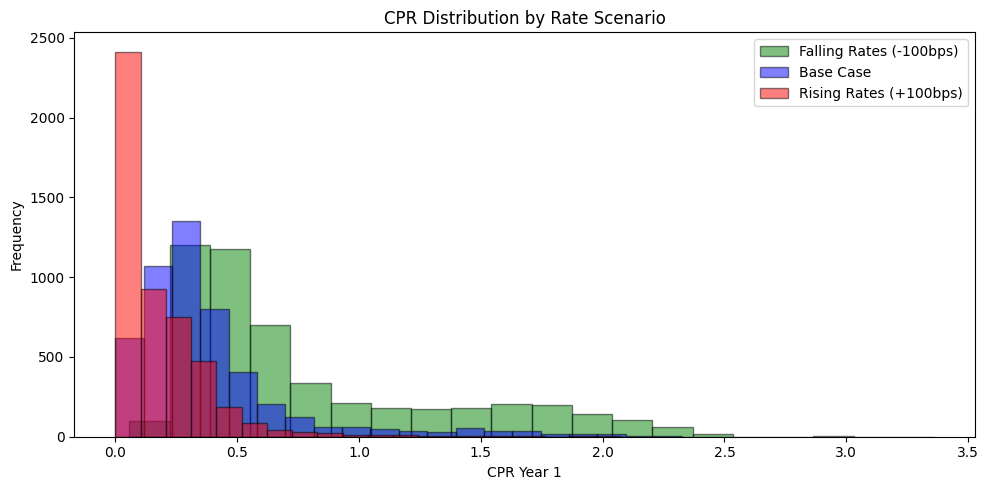

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(annual_prepay_rates_down[:,0], bins=20, alpha=0.5, color='green', label='Falling Rates (-100bps)', edgecolor='black')
ax.hist(annual_prepay_rates[:,0], bins=20, alpha=0.5, color='blue', label='Base Case', edgecolor='black')
ax.hist(annual_prepay_rates_up[:,0],   bins=20, alpha=0.5, color='red',   label='Rising Rates (+100bps)', edgecolor='black')
ax.set_xlabel('CPR Year 1')
ax.set_ylabel('Frequency')
ax.set_title('CPR Distribution by Rate Scenario')
ax.legend()
plt.tight_layout()
plt.show()

Sensitivity analysis showing CPR distributions shift rightward as rates fall — rising rates suppress prepayments almost entirely (red bar concentrated at zero) while falling rates produce significantly higher CPR, confirming the model correctly captures the inverse relationship between interest rates and prepayment incentives.

### End of Notebook